Perfecto. Dejo **constancia clara de por dónde vamos** y luego te doy **el script Python** tal y como lo necesitas.

---

## 🧭 DÓNDE NOS QUEDAMOS (para retomarlo después)

### Creación de imágenes didácticas para UD4

* ✅ **Capítulo 1**

  * Imágenes introductorias (ML vs DL, pipeline, inspiración biológica)
  * Poco peso visual, solo contextual

* 🔴 **Capítulo 2 (CLAVE)**

  * Escalares, vectores, matrices, tensores
  * Batches
  * Broadcasting
  * Producto matricial
  * Interpretación geométrica
  * Superficie de pérdida (entrada al gradiente)

⏸️ **Punto exacto actual**
👉 Estamos **justo antes de entrar en Capítulo 3: Gradiente descendente y backpropagation**, y ya has pedido material **visual y computacional** para explicar el descenso de gradiente.

Esto lo retomamos luego **con imágenes + notebooks + diagramas**.

---

## 🧪 SCRIPT PYTHON — Superficie de pérdida + Gradiente descendente

Este script:

* Define una **función de pérdida no trivial**
* Tiene **varios mínimos locales**
* Aplica **gradiente descendente**
* Dibuja:

  * la superficie
  * el recorrido del algoritmo paso a paso

### 📌 Qué puedes hacer con esto

* Ejecutarlo en notebook o script
* Guardar las figuras
* Usarlas luego en el documento teórico
* Animarlo si quieres (paso siguiente)

---

### 🧩 Script completo (NumPy + Matplotlib)



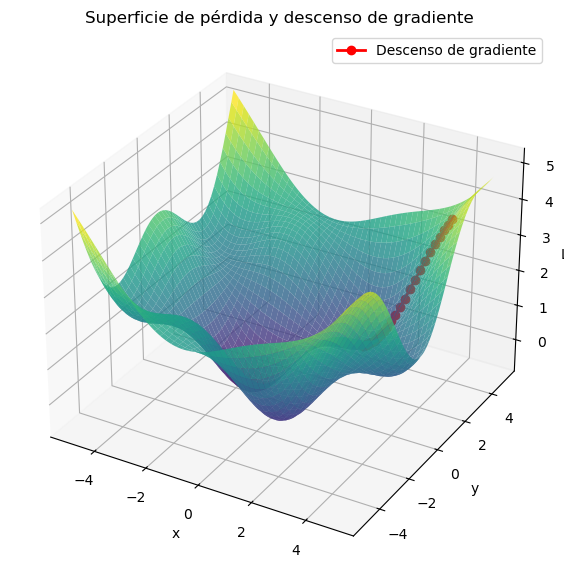

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# ---------------------------
# 1. Función de pérdida
# ---------------------------
def loss_function(x, y):
    """
    Superficie con varios mínimos locales
    """
    return (
        np.sin(x) * np.cos(y)
        + 0.1 * (x**2 + y**2)
    )

# Gradiente analítico
def grad_loss(x, y):
    dx = np.cos(x) * np.cos(y) + 0.2 * x
    dy = -np.sin(x) * np.sin(y) + 0.2 * y
    return dx, dy

# ---------------------------
# 2. Crear superficie
# ---------------------------
x_vals = np.linspace(-5, 5, 200)
y_vals = np.linspace(-5, 5, 200)
X, Y = np.meshgrid(x_vals, y_vals)
Z = loss_function(X, Y)

# ---------------------------
# 3. Gradiente descendente
# ---------------------------
lr = 0.1
steps = 30

x, y = 4.0, 4.0  # punto inicial
trajectory = []

for _ in range(steps):
    trajectory.append((x, y, loss_function(x, y)))
    dx, dy = grad_loss(x, y)
    x -= lr * dx
    y -= lr * dy

trajectory = np.array(trajectory)

# ---------------------------
# 4. Visualización 3D
# ---------------------------
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")

ax.plot_surface(X, Y, Z, cmap="viridis", alpha=0.8)
ax.plot(
    trajectory[:, 0],
    trajectory[:, 1],
    trajectory[:, 2],
    color="red",
    marker="o",
    linewidth=2,
    label="Descenso de gradiente"
)

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("Loss")
ax.set_title("Superficie de pérdida y descenso de gradiente")

ax.legend()
plt.show()


## 🧠 Explicación

Frases clave :

* *“Entrenar un modelo es moverse por esta superficie”*
* *“El gradiente indica la pendiente más pronunciada”*
* *“La tasa de aprendizaje decide cuánto avanzamos”*
* *“No siempre llegamos al mínimo global”*

# 🧪 1️⃣ ANIMACIÓN 3D — Descenso de gradiente

Esta versión es **impactante visualmente** y sirve para:

* reforzar la intuición
* conectar con la “superficie de pérdida”
* preparar el terreno para hablar de *learning rate*

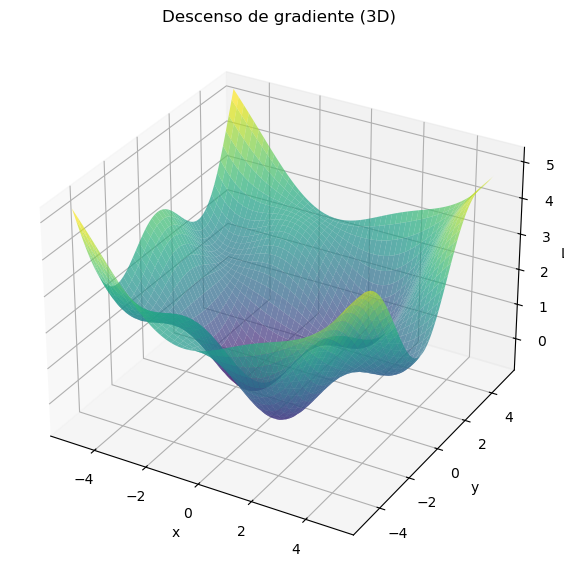

In [2]:
## 📜 Script Python — Animación 3D básica

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from mpl_toolkits.mplot3d import Axes3D

# ---------------------------
# Función de pérdida
# ---------------------------
def loss_function(x, y):
    return np.sin(x) * np.cos(y) + 0.1 * (x**2 + y**2)

def grad_loss(x, y):
    dx = np.cos(x) * np.cos(y) + 0.2 * x
    dy = -np.sin(x) * np.sin(y) + 0.2 * y
    return dx, dy

# ---------------------------
# Superficie
# ---------------------------
x_vals = np.linspace(-5, 5, 150)
y_vals = np.linspace(-5, 5, 150)
X, Y = np.meshgrid(x_vals, y_vals)
Z = loss_function(X, Y)

# ---------------------------
# Gradiente descendente
# ---------------------------
lr = 0.15
steps = 30
x, y = 4.0, 4.0
trajectory = []

for _ in range(steps):
    z = loss_function(x, y)
    trajectory.append((x, y, z))
    dx, dy = grad_loss(x, y)
    x -= lr * dx
    y -= lr * dy

trajectory = np.array(trajectory)

# ---------------------------
# Animación
# ---------------------------
fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection="3d")

ax.plot_surface(X, Y, Z, cmap="viridis", alpha=0.7)
point, = ax.plot([], [], [], "ro", markersize=6)
path, = ax.plot([], [], [], "r--")

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("Loss")
ax.set_title("Descenso de gradiente (3D)")

def update(frame):
    point.set_data(trajectory[frame, 0], trajectory[frame, 1])
    point.set_3d_properties(trajectory[frame, 2])

    path.set_data(trajectory[:frame+1, 0], trajectory[:frame+1, 1])
    path.set_3d_properties(trajectory[:frame+1, 2])
    return point, path

ani = FuncAnimation(fig, update, frames=len(trajectory), interval=300)
plt.show()

## 🧠 Qué decir mientras se ve

> “Esto es literalmente lo que hace una red neuronal cuando entrena.”

---

# 🧪 2️⃣ COMPARACIÓN DE LEARNING RATES

Aquí empieza **la comprensión profunda**.



In [ ]:


## 📜 Script — Varios learning rates (2D comparativo)
learning_rates = [0.01, 0.1, 0.5]
colors = ["blue", "green", "red"]

plt.figure(figsize=(8, 6))
plt.contour(X, Y, Z, levels=30, cmap="viridis")

for lr, color in zip(learning_rates, colors):
    x, y = 4.0, 4.0
    traj_x, traj_y = [], []

    for _ in range(25):
        traj_x.append(x)
        traj_y.append(y)
        dx, dy = grad_loss(x, y)
        x -= lr * dx
        y -= lr * dy

    plt.plot(traj_x, traj_y, marker="o", color=color, label=f"lr={lr}")

plt.legend()
plt.title("Efecto del learning rate en el descenso de gradiente")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

## 🧠 Mensaje clave (importantísimo)

| Learning rate    | Resultado        |
| ---------------- | ---------------- |
| Muy pequeño      | Converge lento   |
| Adecuado         | Converge bien    |
| Demasiado grande | Oscila o diverge |

Aquí **ya se puede hablar** de:

* entrenamiento inestable
* exploding gradients
* necesidad de optimizadores más avanzados

---

# 🧪 3️⃣ DESCENSO QUE DIVERGE (CASO MALO)





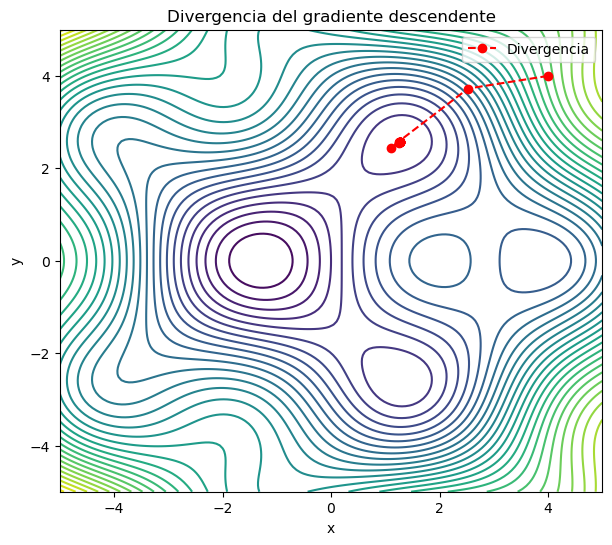

In [3]:
## 📜 Script — Divergencia clara

lr = 1.2  # demasiado grande
x, y = 4.0, 4.0

traj_x, traj_y = [], []

for _ in range(15):
    traj_x.append(x)
    traj_y.append(y)
    dx, dy = grad_loss(x, y)
    x -= lr * dx
    y -= lr * dy

plt.figure(figsize=(7, 6))
plt.contour(X, Y, Z, levels=30, cmap="viridis")
plt.plot(traj_x, traj_y, "ro--", label="Divergencia")
plt.legend()
plt.title("Divergencia del gradiente descendente")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

## 🧠 Frase que clava el concepto

> “Un learning rate demasiado alto hace que el modelo **salte por encima del mínimo** una y otra vez.”

---

# 🧭 Estado exacto del recorrido didáctico

✔ Superficie de pérdida
✔ Gradiente descendente
✔ Learning rate
✔ Convergencia
✔ Divergencia

👉 **Ahora ya podemos entrar con sentido en:**

* backpropagation
* gradientes encadenados
* redes neuronales reales
